In [1]:

import seaborn as sns
import numpy as np

from scipy.stats import poisson
import numpy as np

In [2]:
class Poisson(object):
    cache_pmf = {}
    cache_sf = {}
    cache = {}
    MAX_CUTOFF = 25

    @classmethod
    def pmf_series(cls, mu, cutoff):
        assert isinstance(mu, int), "mu should be an integer."
        assert isinstance(cutoff, int), "cutoff should be an integer"

        if (mu, cutoff) not in cls.cache:
            cls._calculate_pmf_series(mu, cutoff)

        return cls.cache[(mu, cutoff)]

    @classmethod
    def _calculate_pmf_series(cls, mu, cutoff):

        if mu not in cls.cache_pmf:
            print("Calculate poisson ...")
            cls.cache_pmf[mu] = poisson.pmf(np.arange(cls.MAX_CUTOFF + 1), mu)
            cls.cache_sf[mu] = poisson.sf(np.arange(cls.MAX_CUTOFF + 1), mu)

        out = np.copy(cls.cache_pmf[mu][:cutoff+1])
        out[-1] += cls.cache_sf[mu][cutoff]

        cls.cache[(mu, cutoff)] = out

193.3490492751235
134.00426086449983
90.45243773749047
67.59779106615537
53.584930617584064
41.72086291128721
32.72010939685782
26.087556138178172
21.778143392699917
18.31805979033311
15.367406347701888
12.86102712361668
10.739286690815732
8.949004145272568
7.443128433756954
6.180206266078471
5.123897292162269
4.242540347244983
3.5087368683560953
2.8989345554259103
2.393012044082809
1.973873579670851
1.6270638320038415
1.3404108007534319
1.103701663738775
0.9083935811098627
0.747359290960901
0.6146658513105194
0.5053839897123567
0.4154250710594738
0.34140255324280133
0.2805148621151261
0.2304468020147965
0.1892868693017249
0.15545811562594736
0.1276604902645886
0.10482286156803866
0.0860631678041841
0.0706553733336932
0.05800210589359267
0.04761202529920183
0.0390811247288525
0.03207729501582435
0.02632759237292248
0.021607743132562973
0.017733497475092008
0.01455351005540706
0.011943480427248687
0.009801332242659555
46.6554220257932
3.192522050695743
1.6177824456192411
1.1768423418355

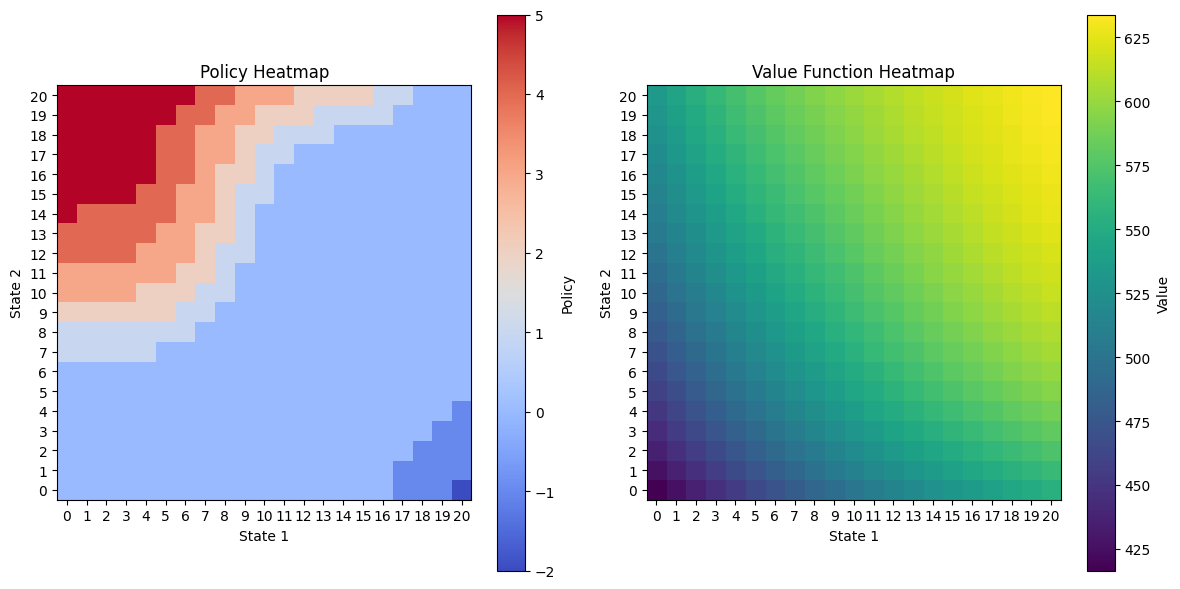

In [5]:
import numpy as np
import matplotlib.pyplot as plt

class PolicyIterationSolver(object):

    capacity = 20
    rental_reward = 10.
    moving_cost = 2.
    max_moving = 5

    bad_action_cost = 100.

    request_mean_G1 = 3
    request_mean_G2 = 4
    return_mean_G1 = 3
    return_mean_G2 = 2

    discount = 0.9

    PolicyEvaluationError = 0.01

    policy = None
    value = None

    def __init__(self):
        self.policy = np.zeros([self.capacity + 1]*2, int)
        self.value = np.zeros([self.capacity + 1]*2)

        self._reward1 = self.expected_rental_reward(self.request_mean_G1)
        self._reward2 = self.expected_rental_reward(self.request_mean_G2)

        assert self.bad_action_cost >= 0

    def bellman(self, action, s1, s2):
        transp1 = self.transition_probabilty(s1, self.request_mean_G1, self.return_mean_G1, -action)
        transp2 = self.transition_probabilty(s2, self.request_mean_G2, self.return_mean_G2, action)
        transp = np.outer(transp1, transp2)

        return self._reward1[s1] + self._reward2[s2] - self.expected_moving_cost(s1, s2, action) + \
               self.discount * sum((transp * self.value).flat)

    def policy_evaluation(self):
        while True:
            diff = 0.
            it = np.nditer([self.policy], flags=['multi_index'])

            while not it.finished:
                action = it[0]
                s1, s2 = it.multi_index

                _temp = self.value[s1, s2]

                self.value[s1, s2] = self.bellman(action=action, s1=s1, s2=s2)

                diff = max(diff, abs(self.value[s1, s2] - _temp))

                it.iternext()

            print(diff)
            if diff < self.PolicyEvaluationError:
                break

    def policy_update(self):
        is_policy_changed = False

        it = np.nditer([self.policy], flags=['multi_index'])
        while not it.finished:
            s1, s2 = it.multi_index

            _max_val = -1
            _pol = None

            for act in range(-self.max_moving, self.max_moving + 1):
                _val = self.bellman(action=act, s1=s1, s2=s2)
                if _val > _max_val:
                    _max_val = _val
                    _pol = act

            if self.policy[s1, s2] != _pol:
                is_policy_changed = True
                self.policy[s1, s2] = _pol

            it.iternext()

        return is_policy_changed

    def expected_moving_cost(self, s1, s2, action):
        if action == 0:
            return 0.

        if action > 0:
            p = self.transition_probabilty(s1, self.request_mean_G1, self.return_mean_G1)
            cost = self._gen_move_cost_array(action)
            return cost.dot(p)

        p = self.transition_probabilty(s2, self.request_mean_G2, self.return_mean_G2)
        cost = self._gen_move_cost_array(action)
        return cost.dot(p)

    def _gen_move_cost_array(self, action):
        _action = abs(action)

        if self.bad_action_cost == 0:
            cost = np.asarray(
                [ii if ii < _action else _action for ii in range(self.capacity+1)]
            ) * self.moving_cost
        else:
            cost = np.asarray(
                [self.bad_action_cost if ii < _action else _action for ii in range(self.capacity + 1)]
            ) * self.moving_cost
        return cost

    @classmethod
    def expected_rental_reward(cls, expected_request):
        return np.asarray([cls._state_reward(s, expected_request) for s in range(cls.capacity + 1)])

    @classmethod
    def _state_reward(cls, s, mu):
        rewards = cls.rental_reward * np.arange(s + 1)
        p = Poisson.pmf_series(mu, cutoff=s)
        return rewards.dot(p)

    def transition_probabilty(self, s, req, ret, action=0):
        _ret_sz = self.max_moving + self.capacity

        p_req = Poisson.pmf_series(req, s)
        p_ret = Poisson.pmf_series(ret, _ret_sz)
        p = np.outer(p_req, p_ret)

        transp = np.asarray([p.trace(offset) for offset in range(-s, _ret_sz + 1)])

        assert abs(action) <= self.max_moving, "action can be large than %s." % self.max_moving

        if action == 0:
            transp[20] += sum(transp[21:])
            return transp[:21]

        if action > 0:
            transp[self.capacity-action] += sum(transp[self.capacity-action+1:])
            transp[self.capacity-action+1:] = 0

            return np.roll(transp, shift=action)[:self.capacity+1]

        action = -action
        transp[action] += sum(transp[:action])
        transp[:action] = 0

        transp[action+self.capacity] += sum(transp[action+self.capacity+1:])
        transp[action+self.capacity+1:] = 0

        return np.roll(transp, shift=-action)[:self.capacity+1]

    def policy_iteration(self):
        self.policy_evaluation()
        while self.policy_update():
            self.policy_evaluation()


solver = PolicyIterationSolver()

for ii in range(4):
    solver.policy_evaluation()
    solver.policy_update()

print(solver.policy)

plt.figure(figsize=(12, 6))

# Heatmap for Policy
plt.subplot(121)
plt.title("Policy Heatmap")
plt.imshow(solver.policy, cmap='coolwarm', origin='lower')
plt.colorbar(label='Policy')
plt.xticks(range(21))
plt.yticks(range(21))
plt.xlabel('State 1')
plt.ylabel('State 2')
plt.grid(False)

# Heatmap for Value Function
plt.subplot(122)
plt.title("Value Function Heatmap")
plt.imshow(solver.value, cmap='viridis', origin='lower')
plt.colorbar(label='Value')
plt.xticks(range(21))
plt.yticks(range(21))
plt.xlabel('State 1')
plt.ylabel('State 2')
plt.grid(False)

plt.tight_layout()
plt.show()


193.3490492751235
134.00426086449983
90.45243773749047
67.59779106615537
53.584930617584064
41.72086291128721
32.72010939685782
26.087556138178172
21.778143392699917
18.31805979033311
15.367406347701888
12.86102712361668
10.739286690815732
8.949004145272568
7.443128433756954
6.180206266078471
5.123897292162269
4.242540347244983
3.5087368683560953
2.8989345554259103
2.393012044082809
1.973873579670851
1.6270638320038415
1.3404108007534319
1.103701663738775
0.9083935811098627
0.747359290960901
0.6146658513105194
0.5053839897123567
0.4154250710594738
0.34140255324280133
0.2805148621151261
0.2304468020147965
0.1892868693017249
0.15545811562594736
0.1276604902645886
0.10482286156803866
0.0860631678041841
0.0706553733336932
0.05800210589359267
0.04761202529920183
0.0390811247288525
0.03207729501582435
0.02632759237292248
0.021607743132562973
0.017733497475092008
0.01455351005540706
0.011943480427248687
0.009801332242659555
53.51739464589684
6.1734677086436704
3.1669552535425964
2.45798444778

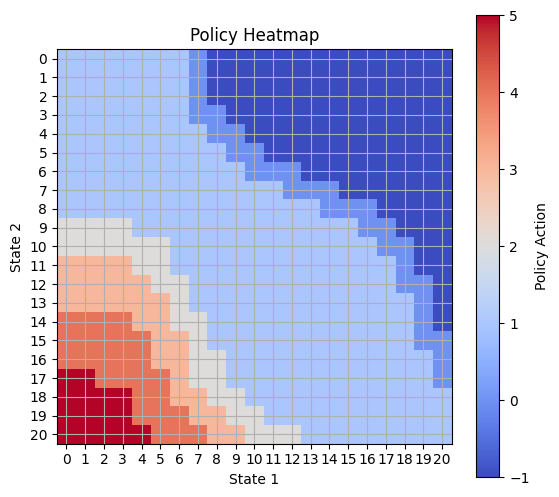

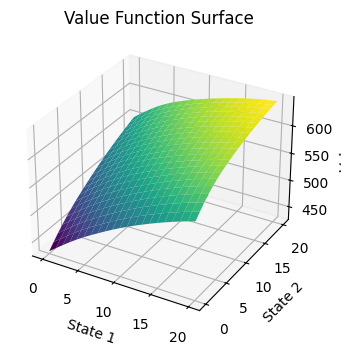

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class PolicyIterationSolver(object):

    capacity = 20
    rental_reward = 10.
    moving_cost = 2.
    max_moving = 5
    parking_cost = 4.


    bad_action_cost = 100.

    request_mean_G1 = 3
    request_mean_G2 = 4
    return_mean_G1 = 3
    return_mean_G2 = 2

    discount = 0.9

    PolicyEvaluationError = 0.01

    policy = None
    value = None

    def __init__(self):
        self.policy = np.zeros([self.capacity + 1]*2, int)
        self.value = np.zeros([self.capacity + 1]*2)

        self._reward1 = self.expected_rental_reward(self.request_mean_G1)
        self._reward2 = self.expected_rental_reward(self.request_mean_G2)

        assert self.bad_action_cost >= 0

    def bellman(self, action, s1, s2):
        transp1 = self.transition_probabilty(s1, self.request_mean_G1, self.return_mean_G1, -action)
        transp2 = self.transition_probabilty(s2, self.request_mean_G2, self.return_mean_G2, action)
        transp = np.outer(transp1, transp2)

        return self._reward1[s1] + self._reward2[s2] - self.expected_moving_cost(s1, s2, action) + \
               self.discount * sum((transp * self.value).flat)

    # policy evaluation
    def policy_evaluation(self):

        while True:
            diff = 0.
            it = np.nditer([self.policy], flags=['multi_index'])

            while not it.finished:
                action = it[0]
                s1, s2 = it.multi_index

                _temp = self.value[s1, s2]

                self.value[s1, s2] = self.bellman(action=action, s1=s1, s2=s2)

                diff = max(diff, abs(self.value[s1, s2] - _temp))

                it.iternext()

            print(diff)
            if diff < self.PolicyEvaluationError:
                break

    def policy_update(self):
        is_policy_changed = False

        it = np.nditer([self.policy], flags=['multi_index'])
        while not it.finished:
            s1, s2 = it.multi_index

            _max_val = -1
            _pol = None

            for act in range(-self.max_moving, self.max_moving + 1):
                _val = self.bellman(action=act, s1=s1, s2=s2)
                if _val > _max_val:
                    _max_val = _val
                    _pol = act

            if self.policy[s1, s2] != _pol:
                is_policy_changed = True
                self.policy[s1, s2] = _pol

            it.iternext()

        return is_policy_changed

    def expected_moving_cost(self, s1, s2, action):
        if action == 0:
            return 0.

        # moving from state s1 into state s2
        if action > 0:
            p = self.transition_probabilty(s1, self.request_mean_G1, self.return_mean_G1)
            cost = self._gen_move_cost_array(action)
            if action > 10:
              cost += self.parking_cost * (action - 10)
            return cost.dot(p)

        # moving from state s2 into state s1
        p = self.transition_probabilty(s2, self.request_mean_G2, self.return_mean_G2)
        cost = self._gen_move_cost_array(action)
        if action > 10:
            cost += self.parking_cost * (action - 10)
        return cost.dot(p)

    def _gen_move_cost_array(self, action):

        _action = abs(action)

        if _action != 0:
          _action -= 1

        # Don't punish bad action:
        if self.bad_action_cost == 0:
            cost = np.asarray(
                [ii if ii < _action else _action for ii in range(self.capacity+1)]
            ) * self.moving_cost

        # bad action is punished
        else:
            cost = np.asarray(
                [self.bad_action_cost if ii < _action else _action for ii in range(self.capacity + 1)]
            ) * self.moving_cost
        return cost


    @classmethod
    def expected_rental_reward(cls, expected_request):
        return np.asarray([cls._state_reward(s, expected_request) for s in range(cls.capacity + 1)])

    @classmethod
    def _state_reward(cls, s, mu):
        rewards = cls.rental_reward * np.arange(s + 1)
        p = Poisson.pmf_series(mu, cutoff=s)
        return rewards.dot(p)

    def transition_probabilty(self, s, req, ret, action=0):


        _ret_sz = self.max_moving + self.capacity

        p_req = Poisson.pmf_series(req, s)
        p_ret = Poisson.pmf_series(ret, _ret_sz)
        p = np.outer(p_req, p_ret)

        transp = np.asarray([p.trace(offset) for offset in range(-s, _ret_sz + 1)])

        assert abs(action) <= self.max_moving, "action can be large than %s." % self.max_moving

        # No GBikes are being moved
        if action == 0:
            transp[20] += sum(transp[21:])
            return transp[:21]

        # Move GBikes from station 1 to station 2
        if action > 0:
            transp[self.capacity-action] += sum(transp[self.capacity-action+1:])
            transp[self.capacity-action+1:] = 0

            return np.roll(transp, shift=action)[:self.capacity+1]

        # Move GBikes from station 2 to station 1
        action = -action
        transp[action] += sum(transp[:action])
        transp[:action] = 0

        transp[action+self.capacity] += sum(transp[action+self.capacity+1:])
        transp[action+self.capacity+1:] = 0

        return np.roll(transp, shift=-action)[:self.capacity+1]

    def policy_iteration(self):

        self.policy_evaluation()
        while self.policy_update():
            self.policy_evaluation()


solver = PolicyIterationSolver()

for ii in range(4):
    solver.policy_evaluation()
    solver.policy_update()

print(solver.policy)

plt.figure(figsize=(14, 6))

# Heatmap for policy
plt.subplot(121)
plt.title('Policy Heatmap')
plt.imshow(solver.policy, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Policy Action')
plt.xlabel('State 1')
plt.ylabel('State 2')
plt.xticks(range(21))
plt.yticks(range(21))
plt.grid(True)

# 3D surface plot for value
X, Y = np.meshgrid(range(21), range(21))
Z = solver.value

fig = plt.figure()
ax = fig.add_subplot(122, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_title('Value Function Surface')
ax.set_xlabel('State 1')
ax.set_ylabel('State 2')
ax.set_zlabel('Value')

plt.tight_layout()
plt.show()
